# Notebook 2: Global Rasterization & Rapid Mask Extraction

**Goal:** Create a high-performance mask generation pipeline. 
Instead of calculating intersections for every building, we:
1. **Rasterize the entire City of Zürich** into one massive binary grid.
2. **Save this Global Raster** to disk so it can be reused instantly without re-processing vectors.
3. **Rapidly Window-Read** 512x512 patches from this file to match our building anchors.

In [9]:
import os
import math
import numpy as np
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Path Configuration
BASE_OUT = "../data/processed_modular"
META_DIR = f"{BASE_OUT}/metadata"
GLOBAL_MASK_PATH = f"{META_DIR}/global_builtup_mask_2056.tif"
MASK_TASK_DIR = "masks_builtup"
GDF_ANCHOR = "building_anchors_20.gpkg"

# Parameters to match Notebook 1
CROP_RADIUS_M = 50 
IMG_SIZE = 512
TARGET_RES = 100.0 / 512.0  # ~0.195m/pixel

In [2]:
# --- 1. Check if Global Mask exists, if not, create it ---
if not os.path.exists(GLOBAL_MASK_PATH):
    print("Global mask not found. Starting vector rasterization (this happens once)...")
    
    # Load Biotope Data
    BIOTOPE_PATH = "/Users/fadricampell/Documents/HSLU/Modules/rBootcamp/r-bootcamp/data/biotoptypen2020/data/gsz.btk_2020.shp"
    gdf = gpd.read_file(BIOTOPE_PATH)
    if gdf.crs.to_string() != 'EPSG:2056':
        gdf = gdf.to_crs(epsg=2056)
    
    # Map class 13 to 1 (Built-up)
    gdf['builtup'] = gdf['lrtyp1code'].apply(lambda x: 1 if str(x) == "13" else 0)
    
    # Define Global Grid
    minx, miny, maxx, maxy = gdf.total_bounds
    width = math.ceil((maxx - minx) / TARGET_RES)
    height = math.ceil((maxy - miny) / TARGET_RES)
    transform = rasterio.transform.from_origin(minx, maxy, TARGET_RES, TARGET_RES)
    
    print(f"Creating {width}x{height} global raster...")
    
    # Rasterize
    global_mask = features.rasterize(
        shapes=((geom, val) for geom, val in zip(gdf.geometry, gdf['builtup'])),
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype=rasterio.uint8
    )
    
    # Save to disk
    with rasterio.open(
        GLOBAL_MASK_PATH, 'w',
        driver='GTiff', height=height, width=width, count=1, 
        dtype=rasterio.uint8, crs='EPSG:2056', transform=transform, compress='lzw'
    ) as ds:
        ds.write(global_mask, 1)
    print(f"✅ Global mask saved to {GLOBAL_MASK_PATH}")
else:
    print(f"✅ Reusing existing global mask: {GLOBAL_MASK_PATH}")

Global mask not found. Starting vector rasterization (this happens once)...
Creating 68819x65138 global raster...
✅ Global mask saved to ../data/processed_modular/metadata/global_builtup_mask_2056.tif


## Rapid Extraction

In [7]:
# Load anchors
gdf_anchors = gpd.read_file(f"{META_DIR}/{GDF_ANCHOR}")

for split in ['train', 'val']:
    os.makedirs(f"{BASE_OUT}/{split}/{MASK_TASK_DIR}", exist_ok=True)

print(f"Extracting patches for {len(gdf_anchors)} buildings...")

with rasterio.open(GLOBAL_MASK_PATH) as src:
    for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
        uid = row['unique_id']
        split = row['split']
        out_path = f"{BASE_OUT}/{split}/{MASK_TASK_DIR}/{uid}_mask.tif"
        
        if os.path.exists(out_path): continue
        
        # Define window in the global file
        window = from_bounds(
            row['x_2056'] - CROP_RADIUS_M, row['y_2056'] - CROP_RADIUS_M,
            row['x_2056'] + CROP_RADIUS_M, row['y_2056'] + CROP_RADIUS_M,
            src.transform
        )
        
        # Read with boundless=True to handle edge cases
        mask_patch = src.read(1, window=window, boundless=True, fill_value=0, out_shape=(IMG_SIZE, IMG_SIZE))
        
        # Save patch
        meta = src.meta.copy()
        meta.update({
            "height": IMG_SIZE, "width": IMG_SIZE, 
            "transform": rasterio.windows.transform(window, src.transform)
        })
        
        with rasterio.open(out_path, 'w', **meta) as dest:
            dest.write(mask_patch, 1)

print("✅ All patches extracted successfully.")

Extracting patches for 20 buildings...


  0%|          | 0/20 [00:00<?, ?it/s]

✅ All patches extracted successfully.


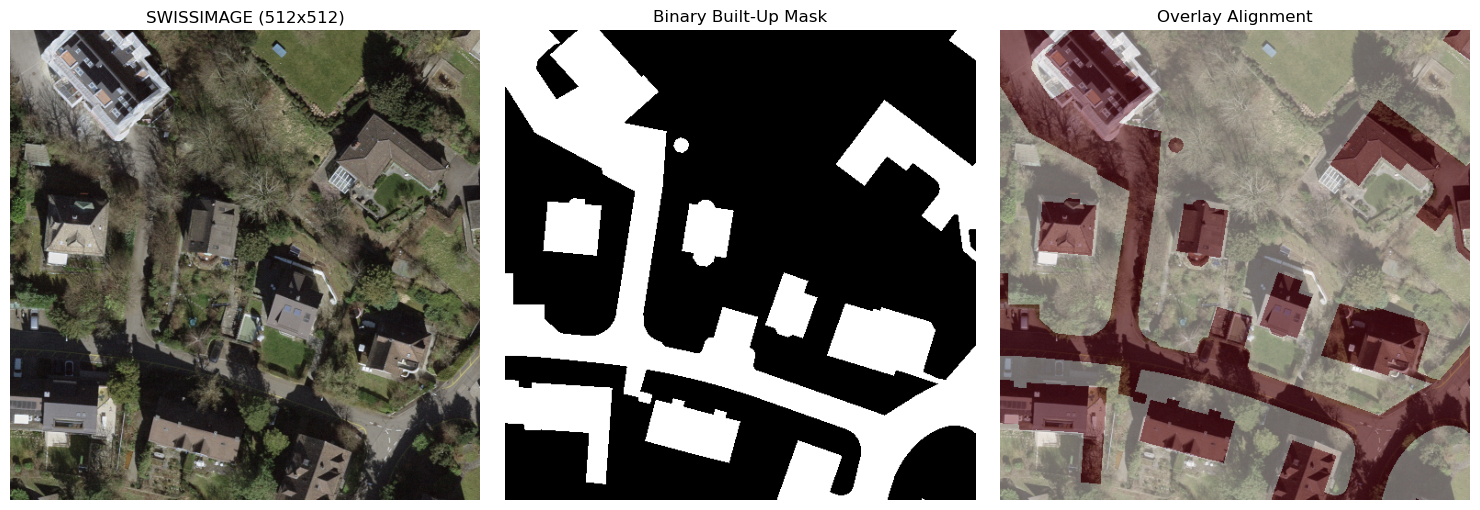

In [15]:
# Grab a random anchor from the training set
sample_row = gdf_anchors[gdf_anchors['split'] == 'train'].sample().iloc[0]
uid = sample_row['unique_id']

img_path = f"{BASE_OUT}/train/images/{uid}_swissimage.tif"
mask_path = f"{BASE_OUT}/train/{MASK_TASK_DIR}/{uid}_mask.tif"

if os.path.exists(img_path) and os.path.exists(mask_path):
    with rasterio.open(img_path) as src_img:
        # Swisstopo might return 3 (RGB) or 4 (RGBA) channels
        img = src_img.read()[:3] 
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = np.moveaxis(img, 0, -1) 
        
    with rasterio.open(mask_path) as src_mask:
        mask = src_mask.read(1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img)
    axs[0].set_title("SWISSIMAGE (512x512)")
    axs[0].axis("off")
    
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Binary Built-Up Mask")
    axs[1].axis("off")
    
    # Overlay
    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="Reds", alpha=0.4) # Overlay mask in semi-transparent red
    axs[2].set_title("Overlay Alignment")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find both files for UID: {uid}. Ensure Notebook 1 ran successfully.")